In [1]:
# Zelle 1: Import testen
from data_reconciliation.io.reader import read_excel
from data_reconciliation.preprocessing.filter import IQRFilter, ResidualFilter, CompositeFilter, filter_report
from data_reconciliation.reconciliation.reconcile import reconcile
from data_reconciliation.visualization.plots import plot_timeseries, plot_corrections
from data_reconciliation.visualization.save import save_figure
from data_reconciliation.reconciliation.balance import compute_mass_balance
from pathlib import Path

print("✓ Alle Module geladen")



✓ Alle Module geladen


In [2]:
# Zelle 2: Daten einlesen
ROOT = Path().resolve().parent        # funktioniert in Notebooks aus notebooks/
data = read_excel(ROOT / "data" / "demo-daten_4.xlsx")
X, A, rho = data["X"], data["A"], data["rho"]
stream_ids         = data["stream_ids"]
stream_meta        = data["stream_meta"]   # dict {int: {klarname, nominal, einheit, typ}}
stream_names       = [stream_meta[sid]["klarname"] for sid in stream_ids]
balance_names     = data["balance_names"]
print(f"X: {X.shape}, A: {A.shape}, rho: {rho}")
print(f"Ströme: {stream_names}")
print(f"Bilanzen: {balance_names}")

X: (3000, 6), A: (3, 6), rho: [0.02  0.05  0.005 0.005 0.02  0.1  ]
Ströme: ['Rohbutan', 'Synthesegas', 'Kreisgas', 'Reaktorausgang', 'Valeraldehyd', 'Purge']
Bilanzen: ['Gesamtbilanz', 'Reaktor', 'Trennung/Flash']


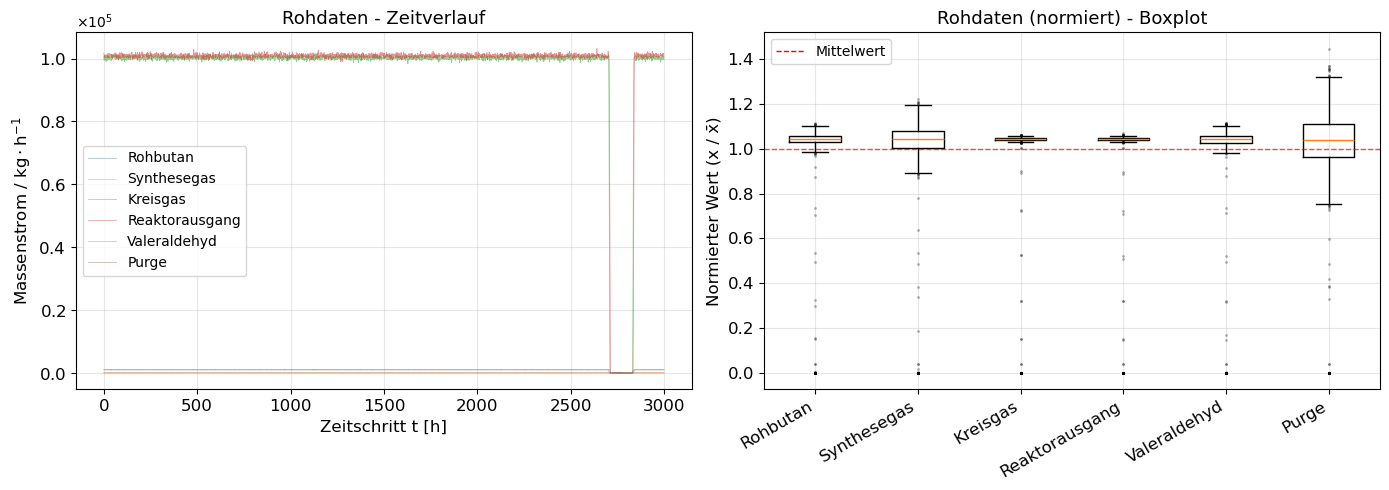

In [3]:
# Plot der Rohdaten
#help(plot_timeseries)
fig1 = plot_timeseries(X, 
                       mask=None,
                       labels=stream_names,
                       normalize=True,
                       sci_left=True,
                       sci_right=False,
                       ylabel_left=r"Massenstrom / $\mathrm{kg \cdot h^{-1}}$",
                       ylabel_right="",
                       title_left="Rohdaten - Zeitverlauf",
                       title_right="Rohdaten (normiert) - Boxplot")
#save_figure(fig1)

---------------------------------------------
  Filterung: 3000 Zeitschritte total
  Behalten:  2774  (92.5%)
  Entfernt:  226  (7.5%)
---------------------------------------------


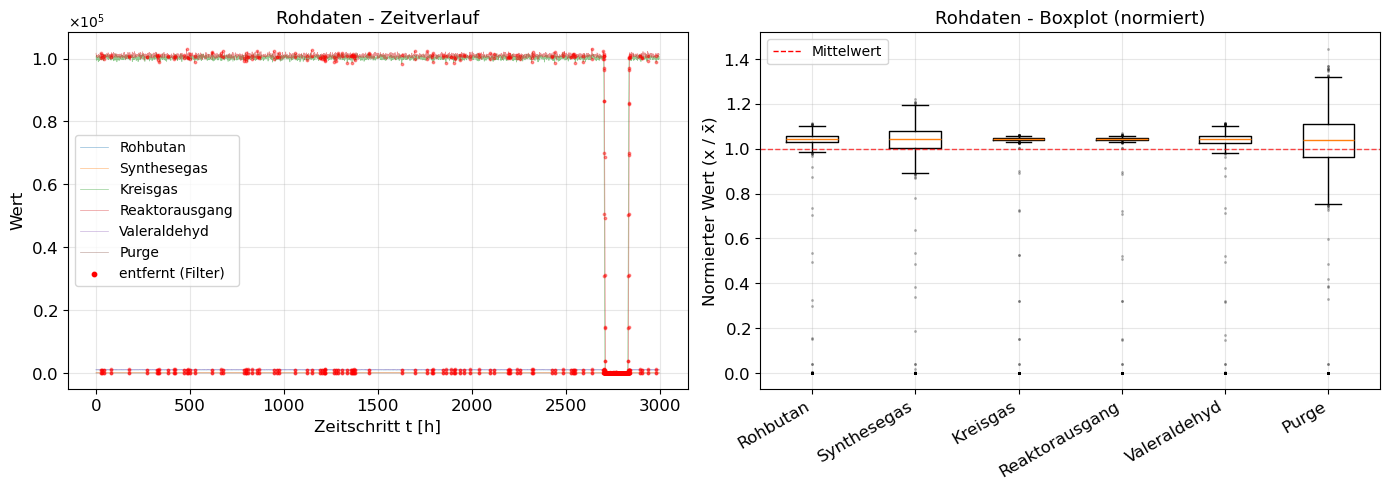

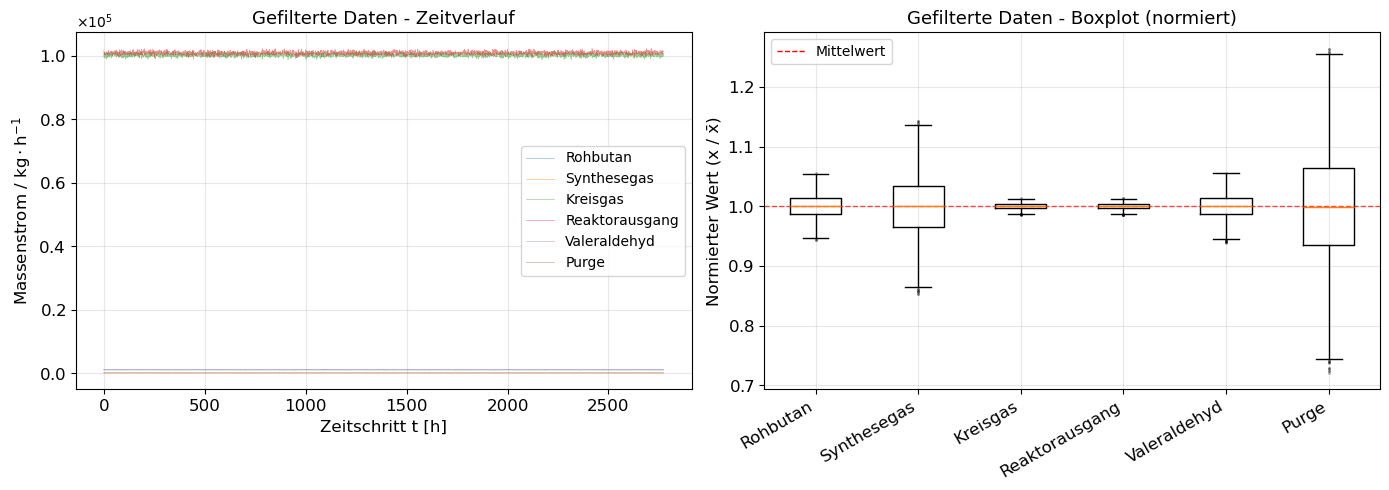

In [4]:
# Zelle 3: Filtern der Daten
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# detailed = f.fit(X).transform_detailed(X)
# mask = detailed["combined"]
# filter_report(mask, detailed)

# Nur IQR-Filter
f = IQRFilter(k=1.5)
mask = f.fit_transform(X)
filter_report(mask)
X_stat = X[mask]

# Zelle 5: Plot der Rohdaten
%matplotlib inline
fig2 = plot_timeseries(X, 
                       mask=mask,
                       labels=stream_names,
                       normalize=True,
                       sci_left=True,
                       sci_right=True,
                       title_left="Rohdaten - Zeitverlauf",
                       title_right="Rohdaten - Boxplot (normiert)")
fig3 = plot_timeseries(X[mask], 
                       mask=None,
                       labels=stream_names,
                       normalize=True,
                       sci_left=True,
                       sci_right=True,
                       ylabel_left=r"Massenstrom / $\mathrm{kg \cdot h^{-1}}$",                      
                       title_left="Gefilterte Daten - Zeitverlauf",
                       title_right="Gefilterte Daten - Boxplot (normiert)")





Mittlere Bilanzabweichung (ungefiltert): [  17.76305667  498.11749667 -480.35444   ]
Mittlere Bilanzabweichung (gefiltert): [  18.7636013   520.34235761 -501.57875631]


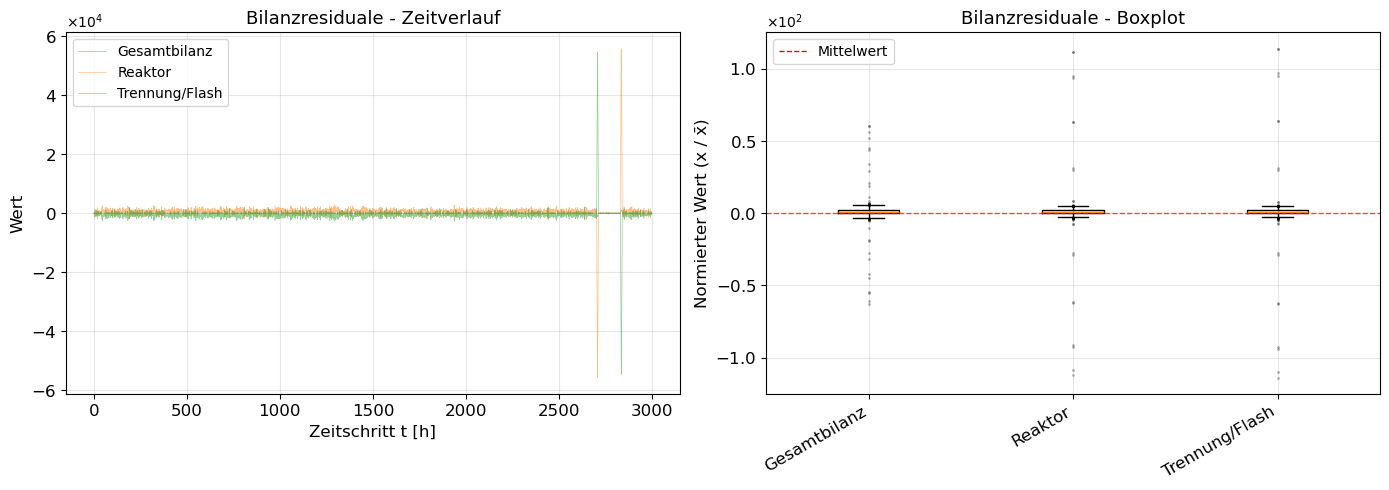

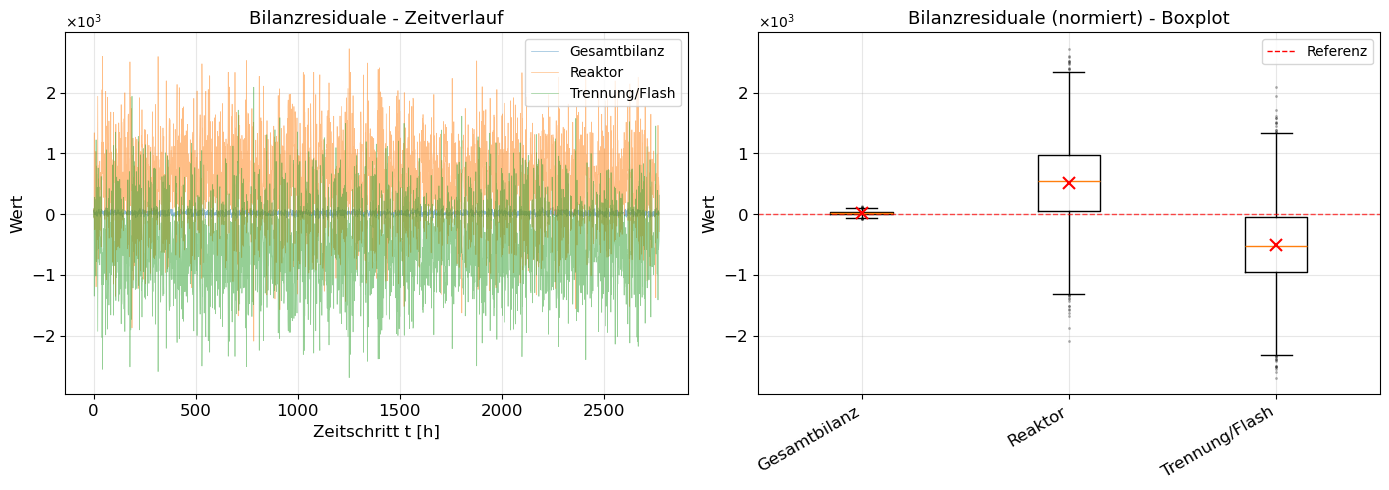

In [5]:
# Massenbilanz ungefiltert
mb_uf = compute_mass_balance(X, A)
print(f'Mittlere Bilanzabweichung (ungefiltert): { mb_uf["residuals_mean"] }')
all_residuals = mb_uf['residuals']
fig1 = plot_timeseries(X=all_residuals,
                    labels=balance_names,
                    title_left= "Bilanzresiduale - Zeitverlauf",
                    title_right= "Bilanzresiduale - Boxplot",
                    xlabel="Zeitschritt t [h]",
                    normalize=True,
                    hline=0,
                    sci_left=True,
                    sci_right=True)


# Massenbilanz gefiltert
mb_f = compute_mass_balance(X_stat, A)
print(f'Mittlere Bilanzabweichung (gefiltert): { mb_f["residuals_mean"] }')
all_residuals = mb_f['residuals']
fig2 = plot_timeseries(X=all_residuals,
                    labels=balance_names,
                    title_left= "Bilanzresiduale - Zeitverlauf",
                    title_right= "Bilanzresiduale (normiert) - Boxplot",
                    xlabel="Zeitschritt t [h]",
                    normalize=False,
                    hline=True,
                    sci_left=True,
                    sci_right=True)

In [6]:
# Zelle 4: Rekonziliation
result = reconcile(X[mask], A, rho)
print(f"Mittlerer SS_res: {result['SS_res'].mean():.6f}")



Mittlerer SS_res: 596.734447


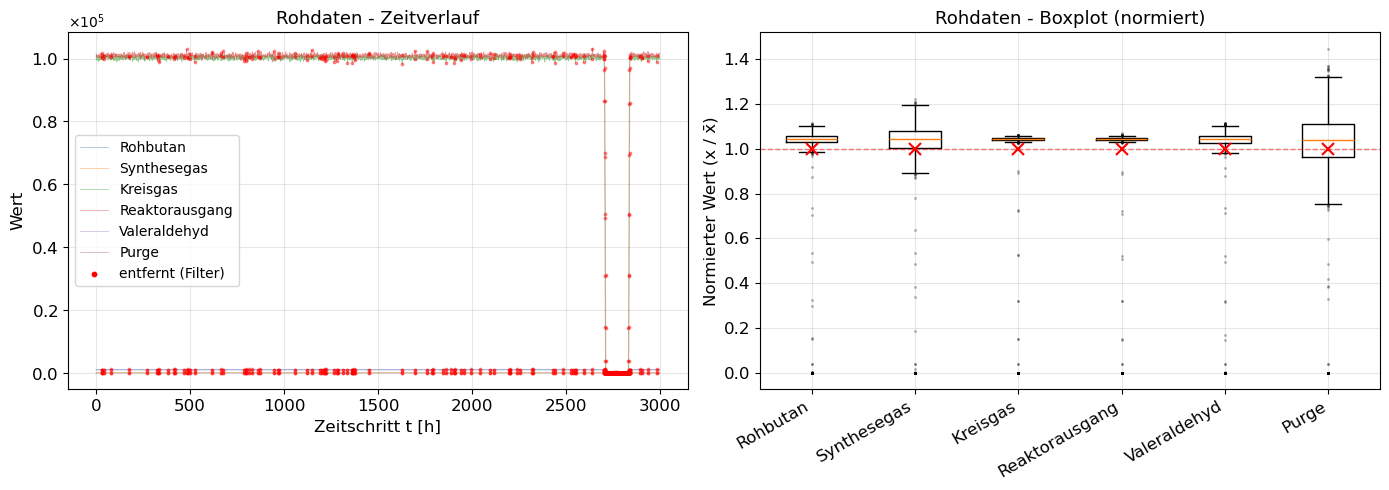

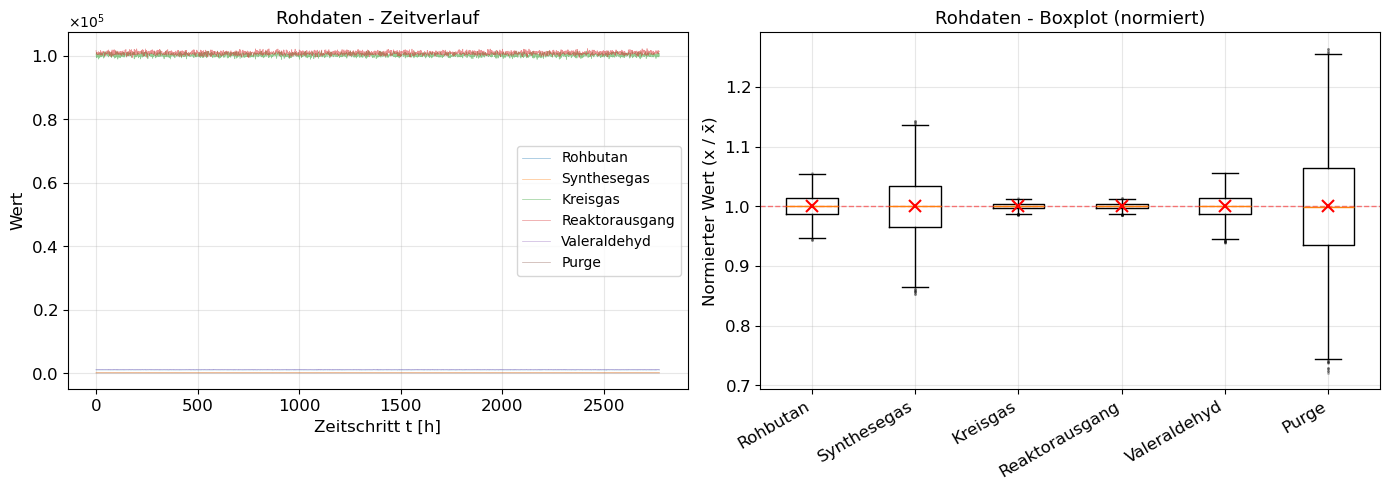

In [6]:
save_figure(fig1)
save_figure(fig2)

  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_zeitverlauf.png  (156 KB)
  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png  (134 KB)


'C:\\Users\\Admin\\Nextcloud-RP\\997_Python-Projekte\\data-reconciliation\\notebooks\\docs\\plots\\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png'